# Hybrid Wind Transformer Notebook

This notebook is a direct `.ipynb` conversion of the code you provided.

It keeps the original project structure in notebook form:
- README notes
- `helper_function.py`
- `layers.py`
- `training_details.py`
- `hybrid_transformer.py`


# Hybrid Transformer Model for Time Series Prediction

Da model

Put all your possibly correlated time series files into the same directory, with the headers "ws". The time_series_slicer class will pick up the columns with "ws" header. Slice them up into sliding windows with a window size 512.

Then run: `python hybrid_transformer.py --lr LR --batch_size BATCH_SIZE --epochs EPOCHS --decay_rate DECAY_RATE`

Here we picked: `lr = 0.001`, `batch_size = 64`, `epochs = 15`, `decay_rate = -0.001`

## Notes

1. Decay rate here refers to decay rate of the learning rate.
2. A single GPU is mostly enough for any kind of purposes.
3. At the end of training process, the model will be saved automatically.
4. If you'd like to replicate the results in the aforementioned article, download the dataset from the original repository. Training the model for 5 or 6 epochs, you should reach approximately 0.992 R² (average of 7 wind farms) score on the test set.

Update: If you are not a Tensorflow lover, for an updated version of this architecture, please go to:
https://github.com/y-akbal/oneforall


In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from time import localtime
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Dense, LSTM, Dropout, Embedding, Attention,
    Conv1D, Conv2D, Layer, LayerNormalization
)
from tensorflow.keras.callbacks import LearningRateScheduler, CSVLogger
from tensorflow.keras.optimizers import Adam

# -----------------------------
# User settings
# -----------------------------
DATA_DIR = "/content/data"   # change if needed
WINDOW_SIZE = 512

LR = 0.001
BATCH_SIZE = 64
EPOCHS = 3
DECAY_RATE = -0.001

print("TensorFlow version:", tf.__version__)
print("Data directory:", DATA_DIR)

TensorFlow version: 2.19.0
Data directory: /content/data


### EDA

In [4]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
benchmark_df = pd.read_csv(os.path.join(DATA_DIR, "benchmark.csv"))

forecast_dfs = {}
for i in range(1, 8):
    forecast_dfs[f"wf{i}"] = pd.read_csv(os.path.join(DATA_DIR, f"windforecasts_wf{i}.csv"))

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
print("benchmark shape:", benchmark_df.shape)

for k, df in forecast_dfs.items():
    print(f"{k} shape:", df.shape)

train shape: (18757, 8)
test shape: (7488, 2)
benchmark shape: (7488, 9)
wf1 shape: (104832, 6)
wf2 shape: (104832, 6)
wf3 shape: (104832, 6)
wf4 shape: (104832, 6)
wf5 shape: (104832, 6)
wf6 shape: (104832, 6)
wf7 shape: (104832, 6)


In [5]:
print("TRAIN")
display(train_df.head())
print(train_df.info())

print("\nTEST")
display(test_df.head())
print(test_df.info())

print("\nBENCHMARK")
display(benchmark_df.head())
print(benchmark_df.info())

print("\nFORECAST WF1")
display(forecast_dfs["wf1"].head())
print(forecast_dfs["wf1"].info())

TRAIN


,date,wp1,wp2,wp3,wp4,wp5,wp6,wp7
0,2009070100,0.045,0.233,0.494,0.105,0.056,0.118,0.051
1,2009070101,0.085,0.249,0.257,0.105,0.066,0.066,0.051
2,2009070102,0.020,0.175,0.178,0.033,0.015,0.026,0.000
3,2009070103,0.060,0.085,0.109,0.022,0.010,0.013,0.000
4,2009070104,0.045,0.032,0.079,0.039,0.010,0.000,0.000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18757 entries, 0 to 18756
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    18757 non-null  int64  
 1   wp1     18757 non-null  float64
 2   wp2     18757 non-null  float64
 3   wp3     18757 non-null  float64
 4   wp4     18757 non-null  float64
 5   wp5     18757 non-null  float64
 6   wp6     18757 non-null  float64
 7   wp7     18757 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 1.1 MB
None

TEST


,id,date
0,4866,2011122106
1,2167,2011060719
2,5522,2012020714
3,6474,2012041518
4,3889,2011101113


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7488 entries, 0 to 7487
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      7488 non-null   int64
 1   date    7488 non-null   int64
dtypes: int64(2)
memory usage: 117.1 KB
None

BENCHMARK


,id,date,wp1,wp2,wp3,wp4,wp5,wp6,wp7
0,1,2011010101,0.551,0.0,0.968,0.645,0.9,0.921,0.833
1,2,2011010102,0.551,0.0,0.968,0.645,0.9,0.921,0.833
2,3,2011010103,0.551,0.0,0.968,0.645,0.9,0.921,0.833
3,4,2011010104,0.551,0.0,0.968,0.645,0.9,0.921,0.833
4,5,2011010105,0.551,0.0,0.968,0.645,0.9,0.921,0.833


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7488 entries, 0 to 7487
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      7488 non-null   int64  
 1   date    7488 non-null   int64  
 2   wp1     7488 non-null   float64
 3   wp2     7488 non-null   float64
 4   wp3     7488 non-null   float64
 5   wp4     7488 non-null   float64
 6   wp5     7488 non-null   float64
 7   wp6     7488 non-null   float64
 8   wp7     7488 non-null   float64
dtypes: float64(7), int64(2)
memory usage: 526.6 KB
None

FORECAST WF1


,date,hors,u,v,ws,wd
0,2009070100,1,2.34,-0.79,2.47,108.68
1,2009070100,2,2.18,-0.99,2.40,114.31
2,2009070100,3,2.20,-1.21,2.51,118.71
3,2009070100,4,2.35,-1.40,2.73,120.86
4,2009070100,5,2.53,-1.47,2.93,120.13


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104832 entries, 0 to 104831
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    104832 non-null  int64  
 1   hors    104832 non-null  int64  
 2   u       93672 non-null   float64
 3   v       93672 non-null   float64
 4   ws      93672 non-null   float64
 5   wd      93672 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 4.8 MB
None


In [6]:
print("Missing values in train:")
display(train_df.isnull().sum())

print("Missing values in test:")
display(test_df.isnull().sum())

print("Missing values in benchmark:")
display(benchmark_df.isnull().sum())

for k, df in forecast_dfs.items():
    print(f"\nMissing values in {k}:")
    display(df.isnull().sum())

Missing values in train:


,0
date,0
wp1,0
wp2,0
wp3,0
wp4,0
wp5,0
wp6,0
wp7,0


Missing values in test:


,0
id,0
date,0


Missing values in benchmark:


...

,0
date,0
hors,0
u,11160
v,11160
ws,11160
wd,11160



Missing values in wf6:


,0
date,0
hors,0
u,11160
v,11160
ws,11160
wd,11160



Missing values in wf7:


,0
date,0
hors,0
u,11160
v,11160
ws,11160
wd,11160


In [7]:
train_df["date"] = pd.to_datetime(train_df["date"].astype(str), format="%Y%m%d%H")
test_df["date"] = pd.to_datetime(test_df["date"].astype(str), format="%Y%m%d%H")
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"].astype(str), format="%Y%m%d%H")

for k in forecast_dfs:
    forecast_dfs[k]["date"] = pd.to_datetime(
        forecast_dfs[k]["date"].astype(str),
        format="%Y%m%d%H"
    )

print("Converted date columns successfully.")
display(train_df.head())
display(forecast_dfs["wf1"].head())

Converted date columns successfully.


,date,wp1,wp2,wp3,wp4,wp5,wp6,wp7
0,2009-07-01 00:00:00,0.045,0.233,0.494,0.105,0.056,0.118,0.051
1,2009-07-01 01:00:00,0.085,0.249,0.257,0.105,0.066,0.066,0.051
2,2009-07-01 02:00:00,0.020,0.175,0.178,0.033,0.015,0.026,0.000
3,2009-07-01 03:00:00,0.060,0.085,0.109,0.022,0.010,0.013,0.000
4,2009-07-01 04:00:00,0.045,0.032,0.079,0.039,0.010,0.000,0.000


,date,hors,u,v,ws,wd
0,2009-07-01,1,2.34,-0.79,2.47,108.68
1,2009-07-01,2,2.18,-0.99,2.40,114.31
2,2009-07-01,3,2.20,-1.21,2.51,118.71
3,2009-07-01,4,2.35,-1.40,2.73,120.86
4,2009-07-01,5,2.53,-1.47,2.93,120.13


In [8]:
print("Summary statistics for train.csv")
display(train_df.describe())

print("Summary statistics for test.csv")
display(test_df.describe())

for k, df in forecast_dfs.items():
    print(f"\nSummary statistics for {k}")
    display(df[["hors", "u", "v", "ws", "wd"]].describe())

Summary statistics for train.csv


,date,wp1,wp2,wp3,wp4,wp5,wp6,wp7
count,18757,18757.000000,18757.000000,18757.000000,18757.000000,18757.000000,18757.000000,18757.000000
mean,2010-09-11 03:47:54.894705920,0.252388,0.265983,0.334571,0.286173,0.272584,0.286774,0.290542
min,2009-07-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2010-01-12 09:00:00,0.050000,0.042000,0.069000,0.022000,0.040000,0.053000,0.025000
50%,2010-07-26 18:00:00,0.175000,0.164000,0.217000,0.182000,0.157000,0.184000,0.177000
75%,2011-03-29 03:00:00,0.381000,0.423000,0.563000,0.474000,0.415000,0.461000,0.505000
max,2012-06-26 12:00:00,0.947000,0.989000,0.978000,0.992000,0.966000,0.974000,0.960000
std,NaN,0.246381,0.273205,0.318636,0.295069,0.294221,0.283023,0.305272


Summary statistics for test.csv


,id,date
count,7488.000000,7488
mean,3744.500000,2011-09-30 06:30:00
min,1.000000,2011-01-01 01:00:00
25%,1872.750000,2011-05-17 03:45:00
50%,3744.500000,2011-09-30 06:30:00
75%,5616.250000,2012-02-13 09:15:00
max,7488.000000,2012-06-28 12:00:00
std,2161.743741,NaN



Summary statistics for wf1


...

,hors,u,v,ws,wd
count,104832.000000,93672.000000,93672.000000,93672.000000,93672.000000
mean,24.500000,1.320029,0.204778,4.420068,143.144304
std,13.853465,3.179263,3.443071,2.051757,99.434786
min,1.000000,-9.920000,-10.320000,0.020000,0.000000
25%,12.750000,-1.010000,-2.480000,3.000000,59.460000
50%,24.500000,1.340000,0.100000,4.160000,122.990000
75%,36.250000,3.500000,2.740000,5.630000,215.952500
max,48.000000,13.540000,12.080000,15.990000,360.000000



Summary statistics for wf6


,hors,u,v,ws,wd
count,104832.000000,93672.000000,93672.000000,93672.000000,93672.000000
mean,24.500000,1.127301,-0.062641,5.018593,155.094993
std,13.853465,3.434959,4.240144,2.422027,101.762929
min,1.000000,-11.520000,-13.700000,0.020000,0.000000
25%,12.750000,-1.160000,-3.300000,3.250000,68.620000
50%,24.500000,1.180000,-0.240000,4.630000,147.400000
75%,36.250000,3.190000,3.160000,6.480000,222.590000
max,48.000000,14.660000,15.050000,16.400000,360.000000



Summary statistics for wf7


,hors,u,v,ws,wd
count,104832.000000,93672.000000,93672.000000,93672.000000,93672.000000
mean,24.500000,1.168748,-0.125958,5.577154,157.624499
std,13.853465,3.759070,4.801668,2.731846,102.531039
min,1.000000,-12.520000,-15.360000,0.050000,0.000000
25%,12.750000,-1.270000,-3.760000,3.540000,71.090000
50%,24.500000,1.170000,-0.330000,5.190000,151.210000
75%,36.250000,3.320000,3.530000,7.290000,225.310000
max,48.000000,16.230000,16.640000,16.960000,360.000000


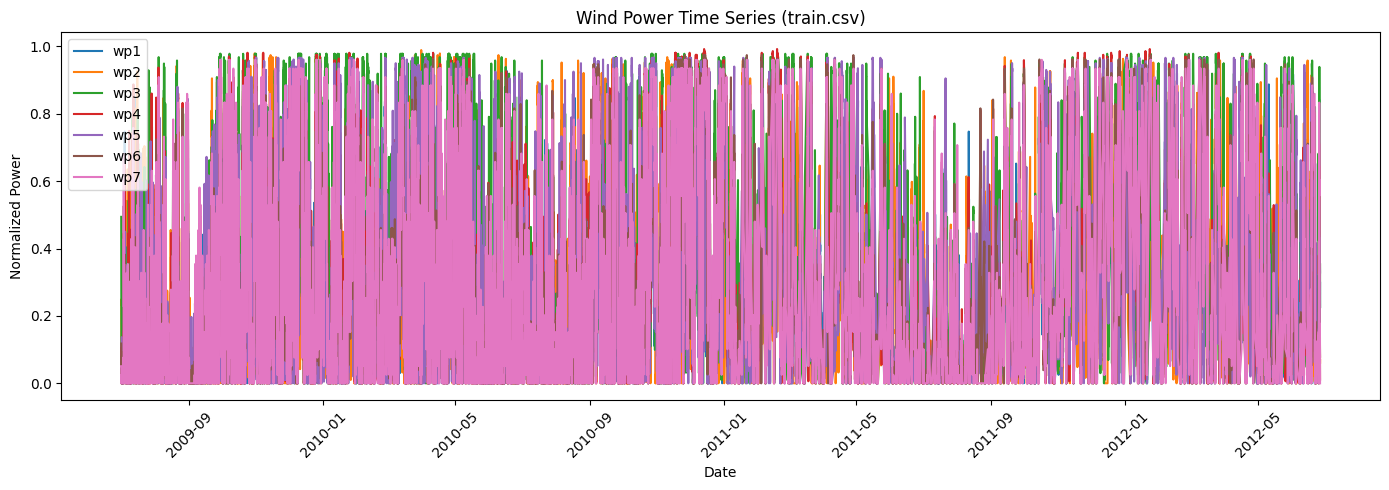

In [9]:
power_cols = ["wp1", "wp2", "wp3", "wp4", "wp5", "wp6", "wp7"]

plt.figure(figsize=(14, 5))
for col in power_cols:
    plt.plot(train_df["date"], train_df[col], label=col)

plt.title("Wind Power Time Series (train.csv)")
plt.xlabel("Date")
plt.ylabel("Normalized Power")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

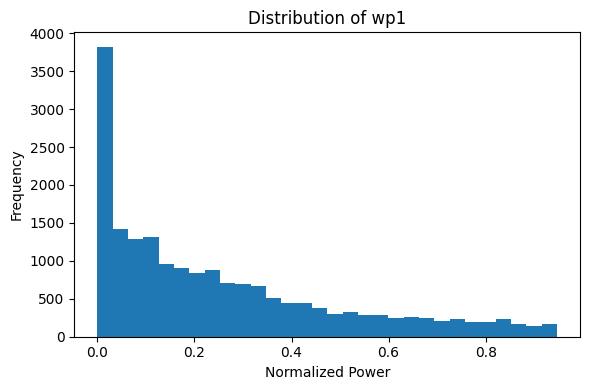

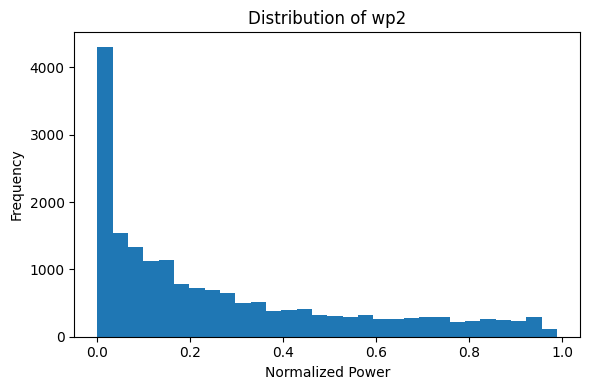

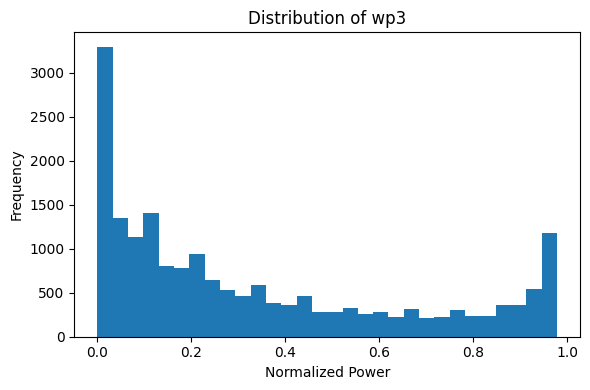

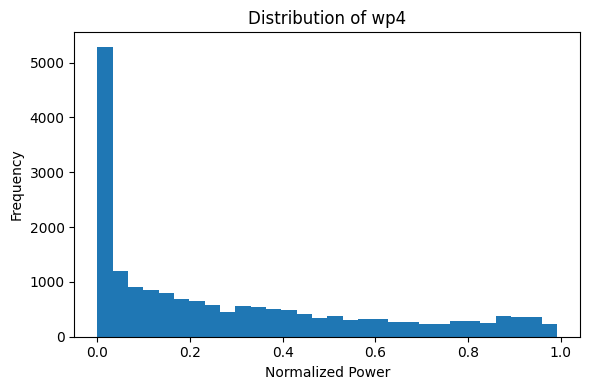

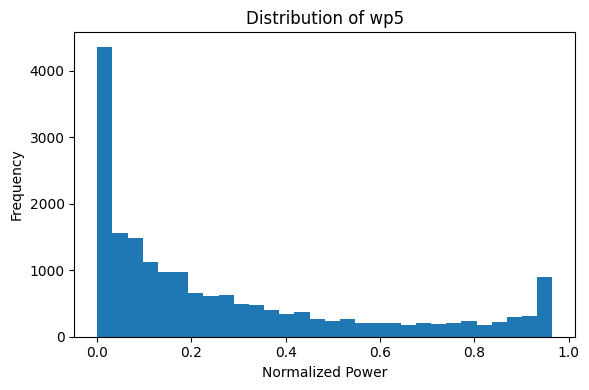

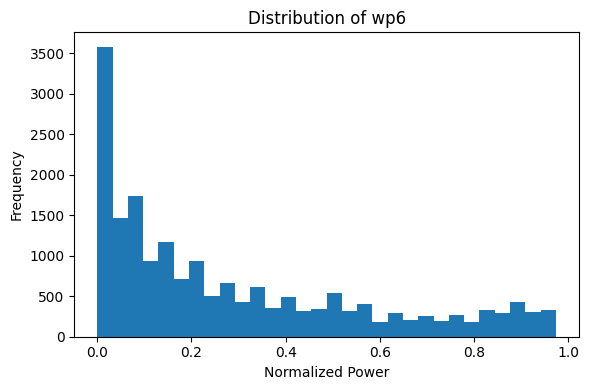

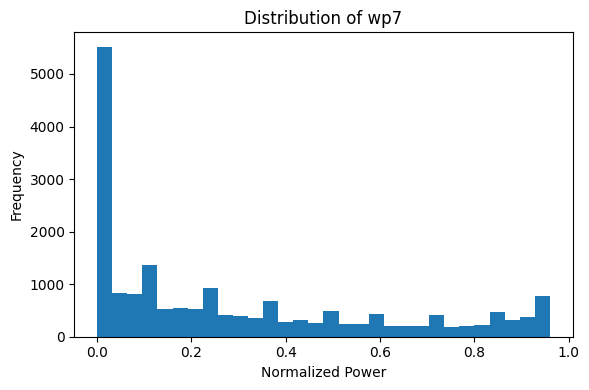

In [10]:
power_cols = ["wp1", "wp2", "wp3", "wp4", "wp5", "wp6", "wp7"]

for col in power_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(train_df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel("Normalized Power")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

,wp1,wp2,wp3,wp4,wp5,wp6,wp7
wp1,1.000000,0.394313,0.608578,0.784888,0.581040,0.733620,0.723803
wp2,0.394313,1.000000,0.394310,0.502267,0.237813,0.487426,0.512764
wp3,0.608578,0.394310,1.000000,0.655927,0.425660,0.676722,0.703215
wp4,0.784888,0.502267,0.655927,1.000000,0.526760,0.912731,0.881610
wp5,0.581040,0.237813,0.425660,0.526760,1.000000,0.510836,0.490625
wp6,0.733620,0.487426,0.676722,0.912731,0.510836,1.000000,0.927958
wp7,0.723803,0.512764,0.703215,0.881610,0.490625,0.927958,1.000000


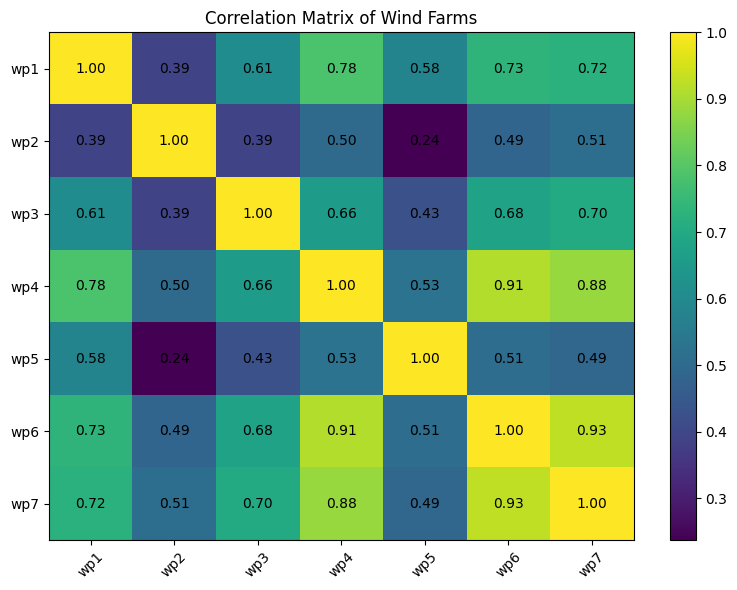

In [12]:
power_cols = ["wp1", "wp2", "wp3", "wp4", "wp5", "wp6", "wp7"]

corr = train_df[power_cols].corr()
display(corr)

plt.figure(figsize=(8, 6))
im = plt.imshow(corr, aspect="auto")
plt.colorbar(im)

plt.xticks(range(len(power_cols)), power_cols, rotation=45)
plt.yticks(range(len(power_cols)), power_cols)
plt.title("Correlation Matrix of Wind Farms")

for i in range(len(power_cols)):
    for j in range(len(power_cols)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

In [15]:
def write_log(a: str, file="log.txt") -> None:
    lt = list(localtime())
    lc = f"{lt[0]}-{lt[1]}-{lt[2]}---{lt[3]}:{lt[4]}"
    with open(file, mode="a") as my_file:
        my_file.write(f"{lc}:\t{a}\n")


def return_files(data_dir="."):
    """
    Read all CSV files in data_dir and keep only those with a 'ws' column.
    """
    files = []
    data = []
    w_files = []

    print("The following files found:")
    total_len = 0

    for file in os.listdir(data_dir):
        if file.endswith(".csv"):
            full_path = os.path.join(data_dir, file)
            try:
                m = pd.read_csv(full_path)["ws"]
                file_len = len(m)
                total_len += file_len
                files.append(file)
                data.append(m)
                print(f"{file} of length {file_len}")
            except KeyError:
                w_files.append(file)

    print(
        f"The total number of observations is {total_len}, "
        f"there are {len(files)} time series to be processed, "
        f"{len(w_files)} csv files do not have column 'ws'."
    )
    return files, data


class time_series_slices:
    def __init__(self, length=64):
        self.length = length

    def __return_preprocessed_data(self, data__, **kwargs):
        data_ = [data.interpolate(**kwargs) for data in data__]
        data_ = [(data - data.mean()) / (data.std() + 1e-8) for data in data_]

        cls_list = []
        X = []
        y = []

        for j, data in enumerate(data_):
            arr = data.to_numpy()
            for i in range(len(arr) - self.length):
                X.append(arr[i:i + self.length])
                y.append(arr[i + self.length])
                cls_list.append(j)

        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), np.array(cls_list, dtype=np.int32)

    def __split_data(self, data_, alpha):
        lens = [len(data) for data in data_]
        n_len = [int(alpha * n) for n in lens]

        data_train = [data[:n].copy() for n, data in zip(n_len, data_)]
        data_test = [data[n:].copy() for n, data in zip(n_len, data_)]

        for data in data_test:
            data.index = range(len(data))

        return data_train, data_test

    def fit_transform(self, data_, alpha=0.8, **kwargs):
        assert isinstance(data_, list)
        assert all(isinstance(data, pd.Series) for data in data_)

        data_train, data_test = self.__split_data(data_, alpha)
        return (
            self.__return_preprocessed_data(data_train, **kwargs),
            self.__return_preprocessed_data(data_test, **kwargs),
        )


write_log("Helper functions loaded successfully.")

files, data_ = return_files(DATA_DIR)
if len(data_) == 0:
    raise ValueError("No CSV files with a 'ws' column were found in DATA_DIR.")

print("Loaded ws series from:", files)

The following files found:
windforecasts_wf5.csv of length 104832
windforecasts_wf1.csv of length 104832
windforecasts_wf6.csv of length 104832
windforecasts_wf3.csv of length 104832
windforecasts_wf2.csv of length 104832
windforecasts_wf7.csv of length 104832
windforecasts_wf4.csv of length 104832
The total number of observations is 733824, there are 7 time series to be processed, 3 csv files do not have column 'ws'.
Loaded ws series from: ['windforecasts_wf5.csv', 'windforecasts_wf1.csv', 'windforecasts_wf6.csv', 'windforecasts_wf3.csv', 'windforecasts_wf2.csv', 'windforecasts_wf7.csv', 'windforecasts_wf4.csv']


In [16]:
class training_details:
    def __init__(self, lr=0.001, batch_size=64, epochs=15, decay_rate=-0.001):
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs
        self.decay_rate = decay_rate

        self.optimizer = Adam(learning_rate=self.lr)
        self.loss = tf.keras.losses.MeanSquaredError()
        self.lr_scheduler_ = LearningRateScheduler(self.lr_scheduler)
        self.csv_logger = CSVLogger("log.csv")
        self.callbacks = [self.lr_scheduler_, self.csv_logger]

    def lr_scheduler(self, epoch, lr):
        if epoch < 3:
            return lr
        return float(lr * tf.math.exp(self.decay_rate))


td = training_details(
    lr=LR,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    decay_rate=DECAY_RATE
)

print(vars(td))

{'lr': 0.001, 'batch_size': 64, 'epochs': 3, 'decay_rate': -0.001, 'optimizer': <keras.src.optimizers.adam.Adam object at 0x7f70e7fe9a00>, 'loss': <LossFunctionWrapper(<function mean_squared_error at 0x7f711fcaf1a0>, kwargs={})>, 'lr_scheduler_': <keras.src.callbacks.learning_rate_scheduler.LearningRateScheduler object at 0x7f70e7f48920>, 'csv_logger': <keras.src.callbacks.csv_logger.CSVLogger object at 0x7f70e46bb800>, 'callbacks': [<keras.src.callbacks.learning_rate_scheduler.LearningRateScheduler object at 0x7f70e7f48920>, <keras.src.callbacks.csv_logger.CSVLogger object at 0x7f70e46bb800>]}


## Main training script

This is the original script content converted into a notebook cell. Since notebooks do not use command-line arguments the same way as `.py` scripts, you may later want to replace the `argparse` section with normal Python variables.

In [17]:
class upsample_conv(Layer):
    def __init__(self, pool_size=4, lags=256, internal_dim=128, activation="gelu", use_embed=False):
        super().__init__()
        assert (lags / pool_size).is_integer(), "Lag size should be divisible by pool_size"

        self.conv = Conv1D(
            filters=internal_dim,
            kernel_size=pool_size,
            strides=pool_size,
            use_bias=True
        )
        self.activation = tf.keras.activations.get(activation)
        self.norm = LayerNormalization()
        self.use_embed = use_embed

        if use_embed:
            self.embed = Embedding(int(lags / pool_size), internal_dim)
            self.pos_ids = tf.constant([i for i in range(int(lags / pool_size))], dtype=tf.int32)

    def call(self, inputs, training=None):
        x = self.conv(inputs)
        if self.use_embed:
            x = x + self.embed(self.pos_ids)
        x = self.activation(x)
        x = self.norm(x, training=training)
        return x


class self_attention_heads(Layer):
    def __init__(self, heads=5, causal=False, dropout=0.3, **kwargs):
        super().__init__(**kwargs)
        self.causal = causal
        self.heads = heads
        self.dropout = Dropout(dropout)
        self.conv2d = Conv2D(
            1,
            kernel_size=1,
            strides=1,
            use_bias=True,
            kernel_initializer=tf.keras.initializers.Constant(value=1 / self.heads)
        )

    def build(self, input_shape):
        input_shape = input_shape[0]
        shape = (self.heads, input_shape[-2], input_shape[-2])
        initializer = tf.keras.initializers.Orthogonal()
        initial_value = initializer(shape=shape)
        self.kernel = tf.Variable(initial_value=initial_value, trainable=True)

        if self.causal:
            minf = -tf.constant(20000.0)
            mask = tf.fill(shape, minf)
            self.upper_m = minf - tf.linalg.band_part(mask, num_lower=-1, num_upper=0)

    def call(self, inputs, training=None):
        x1, x2 = inputs[0], inputs[1]

        if training:
            x1 = self.dropout(x1, training=training)
            x2 = self.dropout(x2, training=training)

        x1e = tf.expand_dims(x1, axis=-3)
        x2e = tf.expand_dims(x2, axis=-3)

        sim1 = self.kernel @ x1e
        sim2 = self.kernel @ x2e
        att_scores = tf.matmul(sim1, sim2, transpose_b=True)

        if self.causal:
            att_scores = att_scores + self.upper_m

        softmaxed = tf.nn.softmax(att_scores, axis=-2)
        similarity_heads = softmaxed @ x2e
        transposed = tf.transpose(similarity_heads, [0, 2, 3, 1])
        return tf.squeeze(self.conv2d(transposed), -1)


class upsampling_block(Model):
    def __init__(self, pool_size, lags, internal_dim, attention_heads=5, dropout_rate=0.4, causal=False, **kwargs):
        super().__init__()
        self.upsample_conv = upsample_conv(
            pool_size=pool_size,
            lags=lags,
            internal_dim=internal_dim,
            **kwargs
        )
        self.dropout = Dropout(dropout_rate)
        self.dense = Dense(internal_dim)
        self.att = self_attention_heads(
            heads=attention_heads,
            causal=causal,
            dropout=dropout_rate
        )
        self.layer_norm = LayerNormalization()

    def call(self, inputs, training=None):
        t = self.upsample_conv(inputs, training=training)
        x = self.dropout(t, training=training)
        x = self.dense(x)
        x = self.dropout(x, training=training)
        x = self.att([x, x], training=training) + t
        x = self.layer_norm(x, training=training)
        return x


class upsampling_block_with_embedding(Model):
    def __init__(self, pool_size, lags, internal_dim, dropout_rate=0.4, number_embeedings=8, **kwargs):
        super().__init__()
        self.upsample_conv = upsample_conv(
            pool_size=pool_size,
            lags=lags,
            internal_dim=internal_dim,
            use_embed=True
        )
        self.embedding = Embedding(number_embeedings, internal_dim)
        self.dropout = Dropout(dropout_rate)
        self.dense = Dense(internal_dim)
        self.att = Attention()
        self.layer_norm = LayerNormalization()

    def call(self, inputs, training=None):
        inputs_1, inputs_2 = inputs[0], inputs[1]
        embeddings = self.embedding(inputs_2)
        t = self.upsample_conv(inputs_1, training=training)
        x = self.dropout(t, training=training)
        x = self.dense(x) + tf.expand_dims(embeddings, 1)
        x = self.att([x, x], training=training) + t
        x = self.layer_norm(x, training=training)
        return x


print("Custom layers loaded successfully.")

Custom layers loaded successfully.


In [18]:
print("Splitting the above series...")
slicer = time_series_slices(WINDOW_SIZE)
train, test = slicer.fit_transform(data_)

X_train, y_train, train_class = train
X_test, y_test, test_class = test

# Conv1D expects: (batch, steps, channels)
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("Splitting into test and train sets is done!")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("train_class shape:", train_class.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("test_class shape:", test_class.shape)

write_log("Data split and reshaping completed.")

Splitting the above series...
Splitting into test and train sets is done!
X_train shape: (583471, 512, 1)
y_train shape: (583471,)
train_class shape: (583471,)
X_test shape: (143185, 512, 1)
y_test shape: (143185,)
test_class shape: (143185,)


In [19]:
class main_model(Model):
    def __init__(
        self,
        pool_sizes=[8, 4, 2, 1, 1],
        lags=512,
        internal_dims=[128, 256, 256, 256, 256],
        recurent_head_dim=128,
        num_series=7
    ):
        super().__init__()
        assert len(internal_dims) == len(pool_sizes), "Set the internal dims and pool sizes properly"

        self.pool_sizes = pool_sizes
        self.initial_lag = lags
        self.internal_dims = internal_dims
        self._lags = []
        self.set_lags()

        self.lstm = LSTM(recurent_head_dim)
        self.dense = Dense(1)
        self.recurrent_head = Sequential([self.lstm, self.dense])

        self.first_layer = upsampling_block_with_embedding(
            pool_size=pool_sizes[0],
            lags=lags,
            internal_dim=internal_dims[0],
            number_embeedings=num_series
        )

        self.rest = Sequential([
            upsampling_block(i, int(j), k)
            for i, j, k in zip(self.pool_sizes[1:], self._lags[1:], self.internal_dims[1:])
        ])

    def set_lags(self):
        self._lags.append(self.initial_lag)
        for i in self.pool_sizes:
            lag = self._lags[-1] / i
            if lag.is_integer():
                self._lags.append(lag)
            else:
                raise ValueError("Pool sizes do not divide lag sizes cleanly.")

    def fit_(self, training_details_obj):
        print(vars(training_details_obj))

        self.compile(
            loss=training_details_obj.loss,
            optimizer=training_details_obj.optimizer,
            jit_compile=False
        )

        history = self.fit(
            [X_train, train_class],
            y_train,
            batch_size=training_details_obj.batch_size,
            epochs=training_details_obj.epochs,
            validation_data=([X_test, test_class], y_test),
            callbacks=training_details_obj.callbacks,
            verbose=1
        )
        return history

    def call(self, inputs, training=None):
        x = self.first_layer(inputs, training=training)
        x = self.rest(x, training=training)
        x = self.recurrent_head(x)
        return x


print("Main model class loaded successfully.")

Main model class loaded successfully.


In [20]:
write_log("Training started")
print("Building model...")

model = main_model(
    pool_sizes=[8, 4, 2, 1, 1],
    lags=WINDOW_SIZE,
    internal_dims=[128, 256, 256, 256, 256],
    recurent_head_dim=128,
    num_series=len(files)
)

write_log("Model initiated")
print("Starting training...")

history = model.fit_(td)

write_log("Training ended")
print("Training complete")

model.save("hybrid_wind_fixed.keras")
print("Model saved as hybrid_wind_fixed.keras")

Building model...
Starting training...
{'lr': 0.001, 'batch_size': 64, 'epochs': 3, 'decay_rate': -0.001, 'optimizer': <keras.src.optimizers.adam.Adam object at 0x7f70e7fe9a00>, 'loss': <LossFunctionWrapper(<function mean_squared_error at 0x7f711fcaf1a0>, kwargs={})>, 'lr_scheduler_': <keras.src.callbacks.learning_rate_scheduler.LearningRateScheduler object at 0x7f70e7f48920>, 'csv_logger': <keras.src.callbacks.csv_logger.CSVLogger object at 0x7f70e46bb800>, 'callbacks': [<keras.src.callbacks.learning_rate_scheduler.LearningRateScheduler object at 0x7f70e7f48920>, <keras.src.callbacks.csv_logger.CSVLogger object at 0x7f70e46bb800>]}
Epoch 1/3
9117/9117 ━━━━━━━━━━━━━━━━━━━━ 4073s 445ms/step - loss: 0.0563 - val_loss: 0.0403 - learning_rate: 0.0010
Epoch 2/3
9117/9117 ━━━━━━━━━━━━━━━━━━━━ 4118s 452ms/step - loss: 0.0321 - val_loss: 0.0308 - learning_rate: 0.0010
Epoch 3/3
9117/9117 ━━━━━━━━━━━━━━━━━━━━ 4121s 452ms/step - loss: 0.0262 - val_loss: 0.0228 - learning_rate: 0.0010
Training co

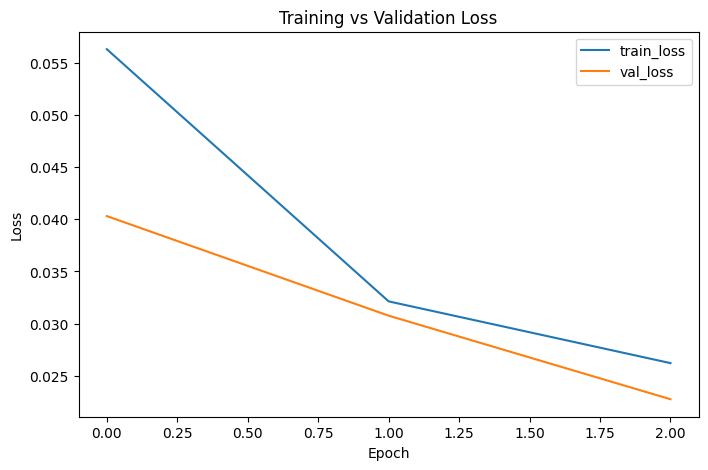

In [21]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [22]:
model.save("hybrid_wind_fixed.keras")

In [23]:
y_pred = model.predict([X_test, test_class], batch_size=BATCH_SIZE)
y_pred = y_pred.squeeze()

2238/2238 ━━━━━━━━━━━━━━━━━━━━ 273s 122ms/step


In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)

MSE: 0.022755425423383713
MAE: 0.07300112396478653
R2: 0.977484941482544


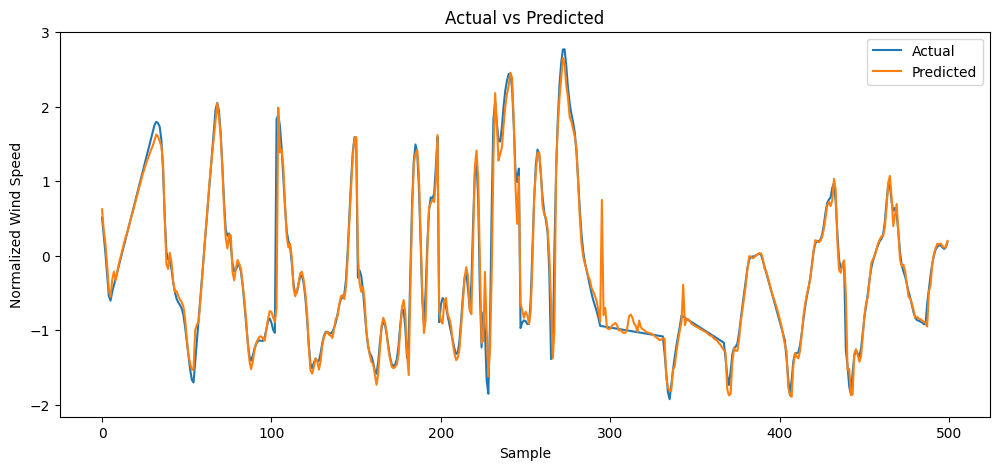

In [25]:
plt.figure(figsize=(12,5))
plt.plot(y_test[:500], label='Actual')
plt.plot(y_pred[:500], label='Predicted')
plt.title('Actual vs Predicted')
plt.xlabel('Sample')
plt.ylabel('Normalized Wind Speed')
plt.legend()
plt.show()